In [22]:
# --- 0) Setup ----------------------------------------------------
from clickhouse_connect import get_client
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

client = get_client(
    host="localhost",
    port=8123,
    database="default",
    username="default",
    password="default",
)


plt.rcParams.update({
    "font.size": 12,          # base font size (match thesis body font)
    "axes.titlesize": 12,     # axes title
    "axes.labelsize": 12,     # x and y labels
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "font.family": "monospace"
})

In [2]:
q_daily = """
WITH d AS (
  SELECT
    submission_date AS day,
    metric,
    sum(toDecimal128(handshakes, 0)) AS hs
  FROM mozilla_telemetry_v2
  GROUP BY day, metric
)
SELECT day, metric, toFloat64(hs) AS handshakes
FROM d
ORDER BY day, metric
"""
df = client.query_df(q_daily)

# 7-day rolling median per metric
def rolling_median(x, win=7):
    return x.rolling(win, min_periods=3, center=True).median()

df['med7'] = (df.groupby('metric')['handshakes']
                .transform(lambda s: rolling_median(s)))
df['ratio_to_med7'] = df['handshakes'] / df['med7']

# flag anomalies only where we actually have a median
df['is_outlier'] = (df['med7'] > 0) & (df['ratio_to_med7'] > 10)

# quick peek at outliers
print(df[df['is_outlier']].sort_values(['metric','ratio_to_med7'], ascending=False).head(20))


           day                           metric    handshakes          med7  \
491 2025-06-22  ssl_handshake_result_ech_grease  1.801445e+16  6.218394e+10   
365 2025-05-22            ssl_handshake_privacy  2.815316e+14  5.588672e+10   
581 2025-07-15            ssl_handshake_privacy  1.779905e+13  5.322135e+10   
653 2025-08-02            ssl_handshake_privacy  4.412904e+12  5.989971e+10   
580 2025-07-15                http3_ech_outcome  4.611686e+18  2.135649e+10   
520 2025-06-30                http3_ech_outcome  1.125922e+15  2.192592e+10   

     ratio_to_med7  is_outlier  
491   2.896961e+05        True  
365   5.037540e+03        True  
581   3.344343e+02        True  
653   7.367153e+01        True  
580   2.159383e+08        True  
520   5.135120e+04        True  


In [3]:
OUTLIER_FACTOR = 50
df_out = df.copy()
df_out['is_outlier'] = (df_out['med7'] > 0) & (df_out['ratio_to_med7'] > OUTLIER_FACTOR)

q_hs_clients = """
WITH d AS (
  SELECT
    submission_date AS day,
    metric,
    sum(toDecimal128(handshakes,0)) AS hs,
    sum(toDecimal128(total_client_count,0)) AS clients
  FROM mozilla_telemetry_v2
  GROUP BY day, metric
)
SELECT day, metric, toFloat64(hs) AS hs, toFloat64(clients) AS clients
FROM d
ORDER BY day, metric
"""
df_hc = client.query_df(q_hs_clients)
df_hc['hs_per_client'] = df_hc['hs'] / df_hc['clients'].replace(0, np.nan)
df_hc['hpc_med7'] = (df_hc.groupby('metric')['hs_per_client']
                       .transform(lambda s: s.rolling(7, min_periods=3, center=True).median()))
df_hc['hpc_outlier'] = (df_hc['hpc_med7']>0) & (df_hc['hs_per_client'] > OUTLIER_FACTOR * df_hc['hpc_med7'])

# Merge the two criteria
bad = (df_out[['day','metric','is_outlier']]
       .merge(df_hc[['day','metric','hpc_outlier']], on=['day','metric'], how='left')
       .assign(is_outlier=lambda d: d['is_outlier'] | d['hpc_outlier'].fillna(False)))

bad_days_per_metric = (bad[bad['is_outlier']]
                       .groupby('metric')['day']
                       .apply(lambda s: set(s))
                       .to_dict())

bad_days_per_metric

{'http3_ech_outcome': {Timestamp('2025-06-30 00:00:00'),
  Timestamp('2025-07-15 00:00:00')},
 'ssl_handshake_privacy': {Timestamp('2025-05-22 00:00:00'),
  Timestamp('2025-07-15 00:00:00'),
  Timestamp('2025-08-02 00:00:00')},
 'ssl_handshake_result_ech_grease': {Timestamp('2025-06-22 00:00:00')}}

In [5]:
q_country_day = """
SELECT country_code, sum(handshakes) AS hs
FROM mozilla_telemetry_v2
WHERE submission_date = '2025-08-02'
  AND metric='http3_ech_outcome'
  AND handshakes > 0
GROUP BY country_code
ORDER BY hs DESC
LIMIT 10
"""
client.query_df(q_country_day)


,country_code,hs
0,US,4144911229
1,DE,1932761763
2,FR,1130296075
3,PL,783018411
4,JP,635868235
5,GB,583522700
6,IN,566952086
7,CA,514467695
8,BR,467245936
9,ID,404615696


In [7]:
# Pull day x metric x country totals once (Decimal to dodge overflow)
q = """
SELECT
  submission_date AS day,
  metric,
  country_code,
  sum(toDecimal128(handshakes,0)) AS hs
FROM mozilla_telemetry_v2
GROUP BY day, metric, country_code
ORDER BY day, metric, country_code
"""
df_mc = client.query_df(q)
df_mc['hs'] = df_mc['hs'].astype(float)

# 7-day rolling median per (metric, country)
def roll_med(s): return s.rolling(7, min_periods=3, center=True).median()

df_mc['med7'] = (df_mc
    .sort_values(['metric','country_code','day'])
    .groupby(['metric','country_code'])['hs']
    .transform(roll_med))

df_mc['ratio_to_med7'] = df_mc['hs'] / df_mc['med7']
# two criteria: huge relative spike OR ridiculous absolute number (e.g., >1e14)
REL_FACTOR = 50
ABS_CAP = 1e14
df_mc['is_country_outlier'] = ((df_mc['med7'] > 0) & (df_mc['ratio_to_med7'] > REL_FACTOR)) | (df_mc['hs'] > ABS_CAP)

# Inspect biggest offenders
print(df_mc[df_mc['is_country_outlier']]
      .sort_values(['metric','hs'], ascending=[True, False])
      .head(20))


              day                           metric country_code            hs  \
91132  2025-07-15                http3_ech_outcome           PL  4.611686e+18   
77887  2025-06-30                http3_ech_outcome           BR  1.125901e+15   
44219  2025-05-22            ssl_handshake_privacy           IE  2.814751e+14   
91370  2025-07-15            ssl_handshake_privacy           PL  1.759512e+13   
107195 2025-08-02            ssl_handshake_privacy           US  4.382835e+12   
68579  2025-06-19            ssl_handshake_privacy           ES  1.386069e+11   
71710  2025-06-22  ssl_handshake_result_ech_grease           SK  1.801441e+16   

                med7  ratio_to_med7  is_country_outlier  
91132   1.224699e+09   3.765565e+09                True  
77887   8.215964e+08   1.370382e+06                True  
44219   9.446082e+07   2.979808e+06                True  
91370   2.800424e+09   6.283020e+03                True  
107195  1.436539e+10   3.050968e+02                True  
685

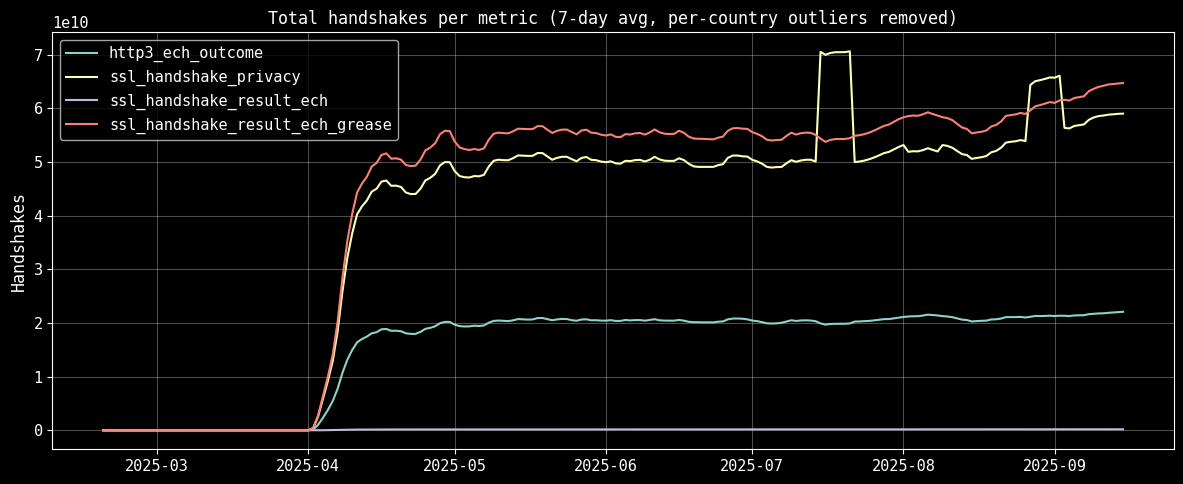

In [8]:
# Remove ONLY the per-(metric,day,country) outliers
bad_rows = df_mc[df_mc['is_country_outlier']][['day','metric','country_code']]
bad_rows['bad'] = True

df_mc2 = (df_mc.merge(bad_rows, on=['day','metric','country_code'], how='left')
                .query("bad != True")
                .drop(columns=['bad']))

# Re-aggregate to day x metric
df_daily_clean = (df_mc2.groupby(['day','metric'], as_index=False)['hs'].sum()
                         .rename(columns={'hs':'handshakes'}))

# Smooth & plot
piv = df_daily_clean.pivot(index='day', columns='metric', values='handshakes').fillna(0)
piv7 = piv.rolling(7, min_periods=1).mean()

plt.figure(figsize=(12,5))
for col in piv7.columns:
    plt.plot(piv7.index, piv7[col], label=col)
plt.title("Total handshakes per metric (7-day avg, per-country outliers removed)")
plt.ylabel("Handshakes")
plt.grid(True, alpha=.3); plt.legend(); plt.tight_layout(); plt.show()


In [9]:
day_peak = (df_daily_clean[df_daily_clean['metric']=='ssl_handshake_privacy']
            .sort_values('handshakes', ascending=False)['day'].iloc[0])

day_str = pd.to_datetime(day_peak).date().isoformat()  # '2025-07-30' etc.

q_priv_breakdown = f"""
SELECT country_code, sum(toDecimal128(handshakes,0)) AS hs
FROM mozilla_telemetry_v2
WHERE submission_date = toDate('{day_str}')
  AND metric='ssl_handshake_privacy'
GROUP BY country_code
ORDER BY hs DESC
LIMIT 15
"""
df_priv_top = client.query_df(q_priv_breakdown)
display(df_priv_top)

# Compare that day's total to local median & dispersion
priv_series = piv['ssl_handshake_privacy']
local_med = priv_series.rolling(7, center=True, min_periods=3).median()
print("ratio to local median:",
      float(priv_series.loc[day_peak] / local_med.loc[day_peak]))


ratio to local median: 3.8316348387143706


In [10]:
# Build country x day series for privacy
q_priv = f"""
SELECT submission_date AS day, country_code,
       sum(toDecimal128(handshakes,0)) AS hs
FROM mozilla_telemetry_v2
WHERE metric='ssl_handshake_privacy'
GROUP BY day, country_code
"""
df_priv = client.query_df(q_priv)
df_priv['hs'] = df_priv['hs'].astype(float)

# 7-day rolling median per country
df_priv = df_priv.sort_values(['country_code','day'])
df_priv['med7'] = (df_priv.groupby('country_code')['hs']
                   .transform(lambda s: s.rolling(7, min_periods=3, center=True).median()))
# Pick the late-July peak day from your cleaned series
day_str = pd.to_datetime(day_peak).date().isoformat()

snap = df_priv[df_priv['day'] == day_peak].copy()
snap['ratio_to_med7'] = snap['hs'] / snap['med7']

# Top contributors + their ratios
snap_top = snap.sort_values('hs', ascending=False).head(15)[['country_code','hs','ratio_to_med7']]
display(snap_top)

# How widespread is the lift?
print("Median ratio across top-15 countries:",
      float(snap_top['ratio_to_med7'].median()))


Median ratio across top-15 countries: 1.055363803430966


In [11]:
day_str = pd.to_datetime(day_peak).date().isoformat()  # e.g. '2025-07-15'

q = f"""
WITH hist AS (
  SELECT
    submission_date AS day,
    country_code,
    sum(toDecimal128(handshakes,0))        AS hs,
    sum(toDecimal128(total_client_count,0)) AS clients
  FROM mozilla_telemetry_v2
  WHERE metric = 'ssl_handshake_privacy'
  GROUP BY day, country_code
),
hist2 AS (
  SELECT
    country_code,
    day,
    toFloat64(hs)      AS hs,
    toFloat64(clients) AS clients,
    (toFloat64(hs) / NULLIF(toFloat64(clients), 0)) AS hs_per_client,
    /* 7-day rolling median per country */
    quantileExact(0.5)(
      toFloat64(hs) / NULLIF(toFloat64(clients), 0)
    ) OVER (
      PARTITION BY country_code
      ORDER BY day
      ROWS BETWEEN 3 PRECEDING AND 3 FOLLOWING
    ) AS hpc_med7
  FROM hist
)
SELECT country_code, hs, clients, hs_per_client, hpc_med7
FROM hist2
WHERE day = toDate('{day_str}')
ORDER BY hs DESC
LIMIT 20
"""
df_hpc = client.query_df(q)
df_hpc['hpc_ratio'] = df_hpc['hs_per_client'] / df_hpc['hpc_med7']
df_hpc.head(12)


,country_code,hs,clients,hs_per_client,hpc_med7,hpc_ratio
0,PL,1.759512e+13,11720178.0,1.501267e+06,241.203219,6224.077164
1,US,1.632914e+11,67215155.0,2.429384e+03,192.489705,12.620852
2,DE,7.011233e+09,37581340.0,1.865616e+02,185.056762,1.008132
3,FR,3.495492e+09,19113465.0,1.828811e+02,187.556558,0.975072
4,RU,1.993407e+09,8844987.0,2.253714e+02,225.371395,1.000000
5,BR,1.879772e+09,12195572.0,1.541356e+02,154.135627,1.000000
6,JP,1.798569e+09,6303869.0,2.853119e+02,285.311900,1.000000
7,IN,1.697049e+09,15211687.0,1.115622e+02,110.665825,1.008100
8,CN,1.686080e+09,11287572.0,1.493749e+02,151.479502,0.986106
9,IT,1.642601e+09,8288804.0,1.981710e+02,194.707399,1.017789


In [12]:
q_good = """
WITH daily AS (
  SELECT
    submission_date AS day,
    sum(handshakes) AS hs_total,
    sumIf(handshakes, country_code != 'OTHER') AS hs_non_other
  FROM mozilla_telemetry_v2
  GROUP BY day
)
SELECT day
FROM daily
WHERE toFloat64(hs_non_other) / nullIf(toFloat64(hs_total),0) >= 0.95
ORDER BY day
"""
good_days = client.query_df(q_good)['day']
good_days_set = set(pd.to_datetime(good_days))
print("Good-geo days:", len(good_days_set), "from", min(good_days_set).date(), "to", max(good_days_set).date())


Good-geo days: 172 from 2025-02-26 to 2025-09-15


In [13]:
# Day × metric × country totals (filtered to good-geo days, and exclude OTHER for detection)
q_mc = """
SELECT
  submission_date AS day,
  metric,
  country_code,
  sum(toDecimal128(handshakes,0))         AS hs,
  sum(toDecimal128(total_client_count,0)) AS clients
FROM mozilla_telemetry_v2
GROUP BY day, metric, country_code
ORDER BY day, metric, country_code
"""
df_mc = client.query_df(q_mc)
df_mc['day'] = pd.to_datetime(df_mc['day'])
df_mc['hs'] = df_mc['hs'].astype(float)
df_mc['clients'] = df_mc['clients'].astype(float)

# keep only good-geo days for outlier detection and drop OTHER here
df_det = df_mc[(df_mc['day'].isin(good_days_set)) & (df_mc['country_code'] != 'OTHER')].copy()

# rolling 7-day medians per (metric,country)
df_det = df_det.sort_values(['metric','country_code','day']).reset_index(drop=True)
def med7(s): return s.rolling(7, min_periods=3, center=True).median()

df_det['hs_med7']  = df_det.groupby(['metric','country_code'])['hs'].transform(med7)
df_det['hpc']      = df_det['hs'] / df_det['clients'].replace(0, np.nan)
df_det['hpc_med7'] = df_det.groupby(['metric','country_code'])['hpc'].transform(med7)

# also a clients median to avoid flukes on tiny client counts
df_det['clients_med7'] = df_det.groupby(['metric','country_code'])['clients'].transform(med7)


In [14]:
# Thresholds (tuned to catch only real artifacts)
REL = {'http3_ech_outcome': 50, 'ssl_handshake_privacy': 8,
       'ssl_handshake_result_ech_grease': 30, 'ssl_handshake_result_ech': 30}
HPC = {'http3_ech_outcome': 8,  'ssl_handshake_privacy': 5,
       'ssl_handshake_result_ech_grease': 8,  'ssl_handshake_result_ech': 8}
ABS = {'http3_ech_outcome': 1e14, 'ssl_handshake_privacy': 1e14,
       'ssl_handshake_result_ech_grease': 1e14, 'ssl_handshake_result_ech': 1e14}

# Floors: only apply relative tests if we have enough signal
HS_FLOOR = {'http3_ech_outcome': 1e9, 'ssl_handshake_privacy': 1e8,
            'ssl_handshake_result_ech_grease': 1e8, 'ssl_handshake_result_ech': 1e7}
CLIENTS_FLOOR = 1e5

rel_fac = df_det['metric'].map(REL).fillna(30)
hpc_fac = df_det['metric'].map(HPC).fillna(8)
abs_cap = df_det['metric'].map(ABS).fillna(1e14)
hs_floor = df_det['metric'].map(HS_FLOOR).fillna(1e8)

# Absolute bomb (near power-of-two etc.)
abs_bomb = df_det['hs'] > abs_cap

# Require BOTH relative spikes (counts AND per-client), and only when medians are meaningful
rel_spike = (
    (df_det['hs_med7']    >= hs_floor) &
    (df_det['clients_med7'] >= CLIENTS_FLOOR) &
    (df_det['hs_med7']    > 0) & (df_det['hpc_med7'] > 0) &
    (df_det['hs']  / df_det['hs_med7']   > rel_fac) &
    (df_det['hpc'] / df_det['hpc_med7']  > hpc_fac)
)

bad_mask = abs_bomb | rel_spike

bad_rows = (df_det.loc[bad_mask, ['day','metric','country_code']]
                 .drop_duplicates()
                 .sort_values(['day','metric','country_code'])
                 .reset_index(drop=True))

print("Outlier rows (strict rules):", len(bad_rows))
display(bad_rows.head(12))

,day,metric,country_code
0,2025-05-22,ssl_handshake_privacy,IE
1,2025-06-19,ssl_handshake_privacy,ES
2,2025-06-22,ssl_handshake_result_ech_grease,SK
3,2025-06-30,http3_ech_outcome,BR
4,2025-07-15,http3_ech_outcome,PL
5,2025-07-15,ssl_handshake_privacy,PL
6,2025-07-15,ssl_handshake_privacy,US
7,2025-08-02,ssl_handshake_privacy,US


In [15]:
# Create table if needed
client.command("""
CREATE TABLE IF NOT EXISTS mozilla_telemetry_outliers
(
  day Date,
  metric LowCardinality(String),
  country_code LowCardinality(String)
)
ENGINE = MergeTree
ORDER BY (day, metric, country_code)
""")

# Refresh table: simple approach — truncate & reinsert
client.command("TRUNCATE TABLE mozilla_telemetry_outliers")
ins = bad_rows.copy()
ins['day'] = pd.to_datetime(ins['day']).dt.date
client.insert_df('mozilla_telemetry_outliers', ins)

client.query_df("SELECT count() AS rows, min(day) AS first_day, max(day) AS last_day FROM mozilla_telemetry_outliers")

,rows,first_day,last_day
0,8,2025-05-22,2025-08-02


In [16]:
q_overview_clean = """
WITH d AS (
  SELECT
    x.submission_date AS day,
    x.metric,
    sum(toDecimal128(x.handshakes,0)) AS hs
  FROM mozilla_telemetry_v2 x
  LEFT JOIN mozilla_telemetry_outliers o
    ON o.day = x.submission_date
   AND o.metric = x.metric
   AND o.country_code = x.country_code
  WHERE o.day IS NULL
  GROUP BY day, metric
)
SELECT day, metric, toFloat64(hs) AS handshakes
FROM d
ORDER BY day, metric
"""


df_over_clean = client.query_df(q_overview_clean)
print(df_over_clean.shape)
print(df_over_clean.columns.tolist())
print(df_over_clean.head(3))



(0, 0)
[]
Empty DataFrame
Columns: []
Index: []


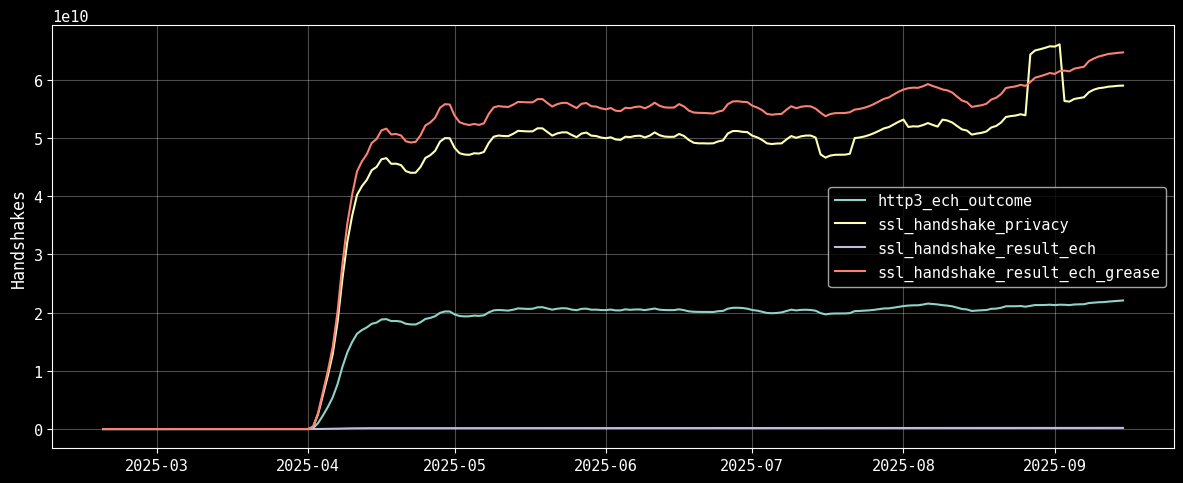

In [17]:
q_overview_clean = """
WITH base AS (
  SELECT
    submission_date AS day,
    metric,
    country_code,
    sum(toDecimal128(handshakes,0)) AS hs
  FROM mozilla_telemetry_v2
  GROUP BY day, metric, country_code
),
clean AS (
  SELECT day, metric, country_code, hs
  FROM base
  WHERE (day, metric, country_code) NOT IN
        (SELECT day, metric, country_code FROM mozilla_telemetry_outliers)
)
SELECT day, metric, toFloat64(sum(hs)) AS handshakes
FROM clean
GROUP BY day, metric
ORDER BY day, metric
"""
df_over_clean = client.query_df(q_overview_clean)
df_over_clean = df_over_clean.rename(columns=str.lower)
df_over_clean['day'] = pd.to_datetime(df_over_clean['day'])

piv = (df_over_clean
       .pivot_table(index='day', columns='metric', values='handshakes', aggfunc='sum')
       .fillna(0))
piv7 = piv.rolling(7, min_periods=1).mean()

plt.figure(figsize=(12,5))
for col in piv7.columns:
    plt.plot(piv7.index, piv7[col], label=col)
#plt.title("Total handshakes per metric (7-day avg, cleaned)")
plt.ylabel("Handshakes"); plt.grid(True, alpha=.3); plt.legend()
plt.tight_layout(); plt.show()

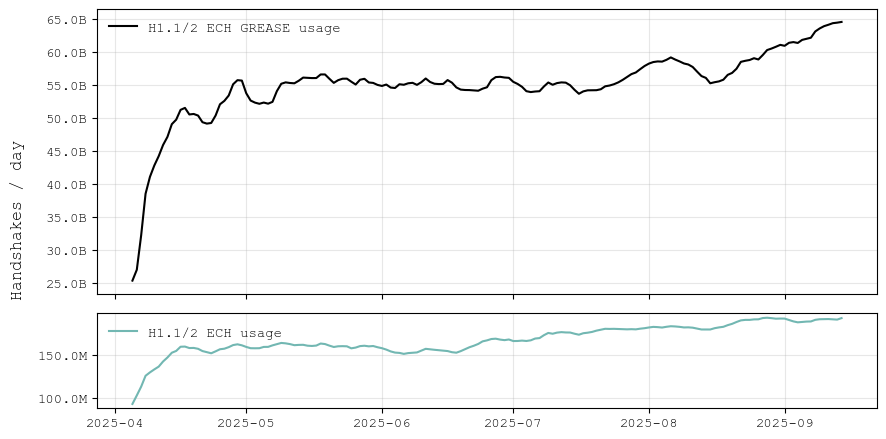

In [18]:
DATE_START = '2025-04-05'
DATE_END   = '2025-09-14'

plt.style.use('default')

plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.monospace'] = ['Courier New', 'Courier', 'DejaVu Sans Mono']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

HEX_GREASE = '#000000'
HEX_NORMAL = "#72B7B2"

q_overview_clean = f"""
WITH base AS (
  SELECT
    submission_date AS day,
    metric,
    country_code,
    sum(toUInt128(handshakes)) AS hs
  FROM mozilla_telemetry_v2
  WHERE submission_date BETWEEN toDate('{DATE_START}') AND toDate('{DATE_END}')
    AND metric IN (
      'ssl_handshake_privacy',
      'http3_ech_outcome',
      'ssl_handshake_result_ech',
      'ssl_handshake_result_ech_grease'
    )
  GROUP BY day, metric, country_code
),
clean AS (
  SELECT day, metric, country_code, hs
  FROM base
  WHERE (day, metric, country_code) NOT IN
        (SELECT day, metric, country_code FROM mozilla_telemetry_outliers)
)
SELECT day, metric, toFloat64(sum(hs)) AS handshakes
FROM clean
GROUP BY day, metric
ORDER BY day, metric
"""
df = client.query_df(q_overview_clean).rename(columns=str.lower)
df['day'] = pd.to_datetime(df['day'])

piv = (df.pivot_table(index='day', columns='metric', values='handshakes', aggfunc='sum')
         .sort_index().fillna(0))
piv7 = piv.rolling(7, min_periods=1).mean()

name_map = {
    'ssl_handshake_result_ech': 'H1.1/2 ECH usage',
    'ssl_handshake_result_ech_grease': 'H1.1/2 ECH GREASE usage',
}

from matplotlib.ticker import FuncFormatter
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(9,4.5), sharex=True, gridspec_kw={'height_ratios':[3,1]}
)

def fmt_si(x,_):
    if x >= 1e12: return f"{x/1e12:.1f}T"
    if x >= 1e9:  return f"{x/1e9:.1f}B"
    if x >= 1e6:  return f"{x/1e6:.1f}M"
    if x >= 1e3:  return f"{x/1e3:.0f}K"
    return f"{int(x)}"

for col in ['ssl_handshake_result_ech_grease']:
    ax1.plot(piv7.index, piv7[col], label=name_map[col], color=HEX_GREASE)
ax1.grid(True, alpha=.3)
ax1.yaxis.set_major_formatter(FuncFormatter(fmt_si))
ax1.legend(loc='upper left', ncols=2, frameon=False)

ax2.plot(piv7.index, piv7['ssl_handshake_result_ech'], label=name_map['ssl_handshake_result_ech'], color=HEX_NORMAL)
fig.supylabel("Handshakes / day", fontsize=12)
ax2.grid(True, alpha=.3)
ax2.yaxis.set_major_formatter(FuncFormatter(fmt_si))
ax2.legend(loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig("handshake_volume_daily.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [19]:
DATE_START = '2025-04-05'
DATE_END   = '2025-09-14'

# --- Query: client-level REAL-ECH share (per your method, with date filter) ---
q_pct_clients_clean = f"""
WITH base AS (
  SELECT
    submission_date AS day,
    country_code,
    key,
    toUInt64(total_client_count) AS clients
  FROM mozilla_telemetry_v2
  WHERE metric = 'ssl_handshake_privacy'
    AND submission_date BETWEEN toDate('{DATE_START}') AND toDate('{DATE_END}')
    AND (submission_date, metric, country_code) NOT IN
        (SELECT day, metric, country_code FROM mozilla_telemetry_outliers)
),
ech AS (
  SELECT day, country_code, max(clients) AS ech_clients
  FROM base
  WHERE bitAnd(toUInt16(key), 8) != 0        -- bit 3 = ECH privacy
  GROUP BY day, country_code
),
allc AS (
  SELECT day, country_code, max(clients) AS all_clients
  FROM base
  GROUP BY day, country_code
),
totals AS (
  SELECT
    a.day,
    sum(e.ech_clients) AS ech_clients,
    sum(a.all_clients) AS all_clients
  FROM allc a
  LEFT JOIN ech e USING(day, country_code)
  GROUP BY a.day
)
SELECT
  toDate(day) AS day,
  ech_clients,
  all_clients,
  toFloat64(ech_clients) / NULLIF(all_clients, 0) AS pct_clients_ech
FROM totals
ORDER BY day
"""

df_pct = client.query_df(q_pct_clients_clean).rename(columns=str.lower)
df_pct['day'] = pd.to_datetime(df_pct['day'])
df_pct['pct_7d'] = df_pct['pct_clients_ech'].rolling(7, min_periods=1).mean()

# Summary numbers for caption/annotation
median_pct = float(df_pct['pct_clients_ech'].median() * 100)
denom_med  = float(df_pct['all_clients'].median())
p10_pct    = float(df_pct['pct_clients_ech'].quantile(0.10) * 100)
p90_pct    = float(df_pct['pct_clients_ech'].quantile(0.90) * 100)

print({
    "days": len(df_pct),
    "median_%": median_pct,
    "p10_%": p10_pct,
    "p90_%": p90_pct,
    "denom_median": denom_med
})

{'days': 163, 'median_%': 21.455358479018834, 'p10_%': 20.47479346195333, 'p90_%': 25.464517556069104, 'denom_median': 45739022.0}


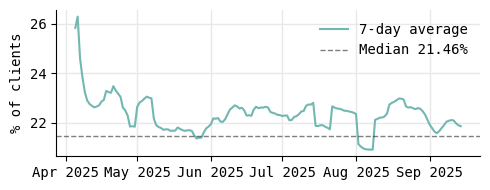

In [23]:
plt.style.use('default')
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.monospace'] = ['DejaVu Sans Mono', 'Courier New', 'Consolas', 'monospace']

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

HEX_GREASE = '#000000'
HEX_NORMAL = '#72B7B2'

fig, ax = plt.subplots(figsize=(5, 2), facecolor='white')

ax.plot(df_pct['day'], df_pct['pct_7d'] * 100, label='7-day average', color=HEX_NORMAL)

ax.axhline(median_pct, ls='--', lw=1, alpha=0.5, label=f'Median {median_pct:.2f}%', color=HEX_GREASE)

ax.set_ylabel("% of clients", fontsize=10)
ax.set_xlabel("")

ax.grid(True, color='#E8E8E8', linestyle='-', linewidth=1, alpha=1.0)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#000000')
ax.spines['bottom'].set_color('#000000')

ax.tick_params(axis='both', colors='#000000', labelsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax.legend(loc='upper right', frameon=False, fontsize=10)

plt.tight_layout()

plt.savefig("daily_pct_real_ech.pdf", format="pdf", bbox_inches="tight", facecolor='white')
plt.show()